In [1]:
#Quick check to debug Nasim's issues
from pathlib import Path
import typing as T
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy
import xarray as xr
import iris
import iris.plot
import numpy as np
import os
import textwrap
import itertools
#import ants
import warnings

In [2]:
VEG_FILE = Path('/scratch/gb02/tmp/qrparm.veg.func')
veg = iris.load(VEG_FILE)
veg

[<iris 'Cube' of canopy_height / (m) (pseudo_level: 5; time: 12; latitude: 310; longitude: 510)>,
<iris 'Cube' of leaf_area_index / (1) (pseudo_level: 5; time: 12; latitude: 310; longitude: 510)>]

In [18]:
MASK_FILE =Path('/scratch/gb02/tmp/qrparm.mask')
mask = iris.load(MASK_FILE)
mask_da = xr.DataArray.from_iris(mask[0])

Ok the so message was 'ERROR : NaNs identified in canopy_height,qrparm.veg.func'

So let's loop through each pseudo level of canopy height and find the location of any NaNs

In [42]:
canopy_height = xr.DataArray.from_iris(veg[0])

In [43]:
for level in range(1,6):
    canopy_height_lvl = canopy_height.sel(pseudo_level=level)
    all_mask = mask_da & canopy_height_lvl.isnull()

    # Compute monthly mean
    all_mask = all_mask.mean('time')
    
    # Find location of NaNs
    all_mask.compute()
    points=all_mask.where(all_mask.compute()==True,drop=True).compute()

    if points:
        print(f'INFO : For level {level} NaNs located at {points.latitude.values},\
{points.longitude.values}')

INFO : For level 1 NaNs located at [-54.6],[158.9]
INFO : For level 2 NaNs located at [-54.6],[158.9]


OK let's look at the data here for level 1 and 2.This looks like the old Macquarie Island Issue.

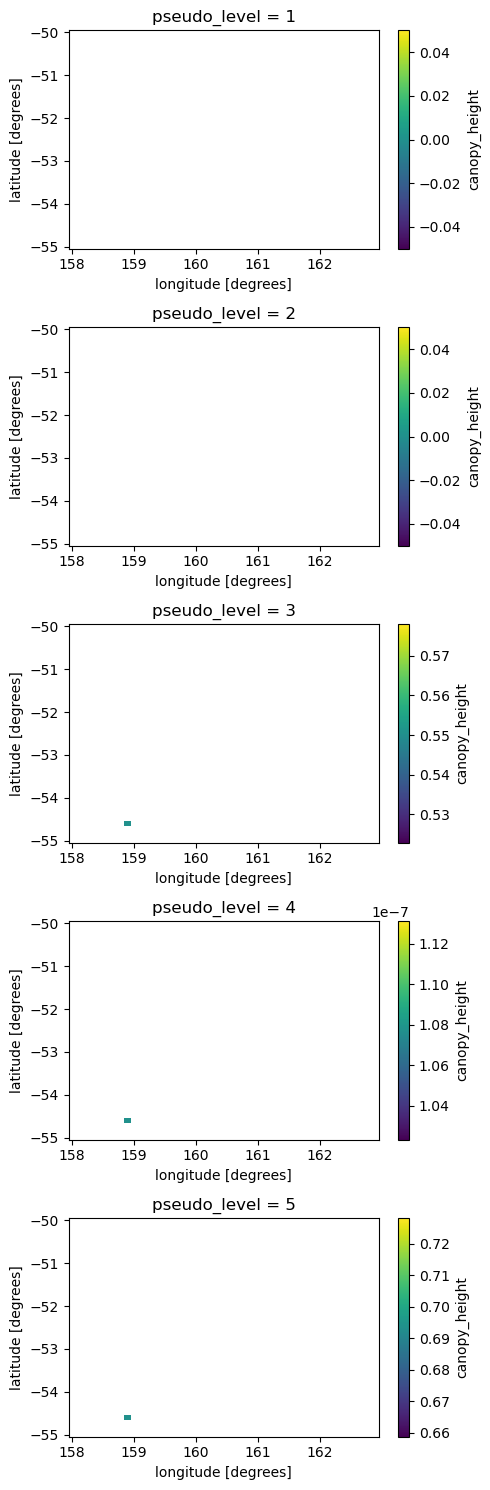

In [54]:
fig,ax=plt.subplots(5,1,figsize=(5,15))

for level in canopy_height.pseudo_level:
    da = canopy_height.sel(pseudo_level=level,latitude=slice(-55,-50),longitude=slice(158,163)).\
         mean('time').plot(ax=ax.flatten()[level-1])
plt.tight_layout()

Note the presence of Macquarie Island (-54.6 S, 158.9 E) in the bottom three plots only